# Sweden CBA / PBA hotspot analysis — EXIOBASE 3 v3.8.2 (v2)

**Project:** RISE pre-study for Region Stockholm. This notebook is the stable national baseline. A later step will layer Stockholm / Rest-of-Sweden disaggregation on top.

**What this notebook does.** A national-level hotspot analysis of Sweden across three dimensions:

1. **Economic importance** — value added (M EUR)
2. **GHG emissions** — total CO2-eq (kt), AR5 GWP100
3. **Material footprint** — kt, aggregated into the four Anthesis primary categories (biomass, fossil, metals, minerals)

For each dimension we compute production-based (PBA) and consumption-based (CBA) accounts, identify top sectors, attribute Sweden's CBA to its source countries and sectors, and trace Sweden's PBA to where it is ultimately consumed.

**Database:** EXIOBASE 3 v3.8.2 (`IOT_2022_pxp.zip`) — free for commercial use.

## Key structural notes (v3.8.2 vs v3.10.1)

EXIOBASE v3.8.2 organises environmental data differently from v3.10.1:

- Only two extensions are exposed: `exio.satellite` (1113 rows, uncharacterised stressors + factor inputs) and `exio.impacts` (126 rows, characterised indicators).
- The satellite extension carries only **22 GHG rows** (vs 420 in v3.10.1) and **does not distinguish fossil from biogenic CO2** (no `CO2_bio`, `CH4_bio`, `N2O_bio` rows).
- Consequently, this notebook reports a single **Total GHG** column (AR5 GWP100) rather than a fossil / biogenic split. A by-gas breakdown (CO2, CH4, N2O, F-gases) is printed once as a diagnostic.
- Material extraction is richer: 217 "Domestic Extraction Used" rows in satellite (vs 62 in v3.10.1). These are mapped by name to the four Anthesis primary categories (biomass, fossil, metals, minerals).
- Value added is read directly from the pre-computed `Value Added` row in the impacts extension.

**Outputs** are written to `./outputs/` (CSV tables and chart PNGs / HTML).


## 1. Setup

In [1]:
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import plotly.express as px

import pymrio

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 200,
                     "axes.titlesize": 11, "axes.labelsize": 9,
                     "xtick.labelsize": 8, "ytick.labelsize": 8})


In [2]:
# ---------- Path configuration -------------------------------------------
EXIOBASE_PATH = r"C:\EXIOBASE3\IOT_2022_pxp.zip"

# ---------- Focus region and analysis knobs -------------------------------
REGION = "SE"          # ISO code for Sweden in EXIOBASE
TOP_N  = 15            # how many entries to show in top-N tables / charts

OUTPUT_DIR = Path("./outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

# ---------- Unit conventions (reference) ---------------------------------
# EXIOBASE v3.8.2 raw units:
#   economic core       : M.EUR  (current prices)
#   satellite GHG rows  : kg (CO2, CH4, N2O, SF6 physical; HFC, PFC already kg CO2-eq)
#   satellite DEU rows  : kt
#   satellite factor    : M.EUR
#   impacts "Value Added": M.EUR
#
# Reporting units used in this notebook:
#   economic : M.EUR (value added)
#   GHG      : kt CO2-eq  (kg -> kt: divide by 1e6)
#   material : kt

print(f"EXIOBASE path  : {EXIOBASE_PATH}")
print(f"Focus region   : {REGION}")
print(f"Top-N          : {TOP_N}")
print(f"Output folder  : {OUTPUT_DIR.resolve()}")


EXIOBASE path  : C:\EXIOBASE3\IOT_2022_pxp.zip
Focus region   : SE
Top-N          : 15
Output folder  : C:\Users\rafaella\OneDrive - RISE\Region Stockholm - Documents\Cirkulär ekonomi\5 Arbetsmaterial och underlag\Dimension_123\outputs


## 2. Load EXIOBASE

We parse the archive with `pymrio.parse_exiobase3`. In v3.8.2 the pre-computed extension multipliers (`S`, `M`) and footprint accounts (`D_cba`, `D_pba`) are already stored inside the archive, which saves one expensive computation for us.

In [3]:
def load_exio(path):
    print(f"Parsing EXIOBASE from: {path}")
    t0 = time.time()
    exio = pymrio.parse_exiobase3(path=path)
    print(f"  parsed in {time.time()-t0:.1f}s")
    print(f"  A shape : {None if exio.A is None else exio.A.shape}")
    print(f"  Y shape : {exio.Y.shape}")
    print(f"  x shape : {None if exio.x is None else exio.x.shape}")
    regions = exio.get_regions().tolist()
    sectors = exio.get_sectors().tolist()
    print(f"  regions : {len(regions)} ({regions[:5]}...)")
    print(f"  sectors : {len(sectors)}")
    for ext_name in ['satellite', 'impacts']:
        ext = getattr(exio, ext_name, None)
        if ext is not None and ext.F is not None:
            S_ok = ext.S is not None
            M_ok = ext.M is not None
            print(f"  ext '{ext_name}': F={ext.F.shape}, "
                  f"S={'Y' if S_ok else 'N'}, M={'Y' if M_ok else 'N'}")
        else:
            print(f"  ext '{ext_name}': NOT FOUND")
    return exio

exio = load_exio(EXIOBASE_PATH)


Parsing EXIOBASE from: C:\EXIOBASE3\IOT_2022_pxp.zip
  parsed in 86.1s
  A shape : (9800, 9800)
  Y shape : (9800, 343)
  x shape : (9800, 1)
  regions : 49 (['AT', 'BE', 'BG', 'CY', 'CZ']...)
  sectors : 200
  ext 'satellite': F=(1113, 9800), S=Y, M=Y
  ext 'impacts': F=(126, 9800), S=Y, M=Y


## 3. Compute the Leontief inverse L

`calc_system()` computes `A = Z · diag(x)⁻¹` (if not already present) and the Leontief inverse `L = (I − A)⁻¹`. This is the single memory-heavy step (~3 GB peak on the 9800×9800 pxp system). We call it only once per kernel session.

In [4]:
if getattr(exio, "L", None) is None:
    print("Computing Leontief inverse L (can take a few minutes)...")
    t0 = time.time()
    exio.calc_system()
    print(f"  L shape: {exio.L.shape}   ({time.time()-t0:.1f}s)")
else:
    print(f"L already computed: {exio.L.shape}. Skipping.")


Computing Leontief inverse L (can take a few minutes)...
  L shape: (9800, 9800)   (2.2s)


## 4. Indicator helpers

### 4.1 Region slicing

In [5]:
def cols_of(df, region):
    """Select columns of a (region, sector)-indexed DataFrame for one region."""
    return df.loc[:, pd.IndexSlice[region, :]]

# Sanity check:
_se_sectors = cols_of(exio.Y, REGION).columns.get_level_values(1).tolist()
print(f"Sweden has {len(_se_sectors)} product sectors. First 5:")
for s in _se_sectors[:5]:
    print(f"  {s}")


Sweden has 7 product sectors. First 5:
  Final consumption expenditure by households
  Final consumption expenditure by non-profit organisations serving households (NPISH)
  Final consumption expenditure by government
  Gross fixed capital formation
  Changes in inventories


### 4.2 GHG aggregation (total, AR5 GWP100)

We aggregate the 22 GHG rows in the satellite extension into a single **Total GHG** stream in kt CO2-eq, using AR5 GWP100 factors. Unit handling per EXIOBASE v3.8.2:

- CO2, CH4, N2O, SF6 rows are physical kg → multiplied by AR5 GWP factor.
- HFC, PFC rows are already **kg CO2-eq** → factor = 1.

As a diagnostic, we also provide a per-gas breakdown (CO2 / CH4 / N2O / F-gases) so the composition can be inspected once.

In [6]:
GWP_AR5 = {"CO2": 1, "CH4": 28, "N2O": 265, "SF6": 23500, "HFC": 1, "PFC": 1}

# All 22 GHG-candidate rows present in v3.8.2 satellite (confirmed via diagnostic).
GHG_ROWS_V382 = {
    "CO2": [
        "CO2 - combustion - air",
        "CO2 - non combustion - Cement production - air",
        "CO2 - non combustion - Lime production - air",
        "CO2 - agriculture - peat decay - air",
    ],
    "CH4": [
        "CH4 - combustion - air",
        "CH4 - non combustion - Extraction/production of (natural) gas - air",
        "CH4 - non combustion - Extraction/production of crude oil - air",
        "CH4 - non combustion - Mining of antracite - air",
        "CH4 - non combustion - Mining of bituminous coal - air",
        "CH4 - non combustion - Mining of coking coal - air",
        "CH4 - non combustion - Mining of lignite (brown coal) - air",
        "CH4 - non combustion - Mining of sub-bituminous coal - air",
        "CH4 - non combustion - Oil refinery - air",
        "CH4 - agriculture - air",
        "CH4 - waste - air",
    ],
    "N2O": [
        "N2O - combustion - air",
        "N2O - agriculture - air",
    ],
    "SF6": ["SF6 - air"],
    "HFC": ["HFC - air"],
    "PFC": ["PFC - air"],
}

def aggregate_ghg(flow_matrix):
    """Aggregate all 22 GHG rows to total kt CO2-eq (kg input, divided by 1e6)."""
    present = set(flow_matrix.index.tolist())
    out = None
    missing = []
    for gas, rows in GHG_ROWS_V382.items():
        gwp = GWP_AR5[gas]
        for row in rows:
            if row in present:
                contrib = flow_matrix.loc[row] * gwp
                out = contrib if out is None else out + contrib
            else:
                missing.append(row)
    if missing:
        print(f"  [aggregate_ghg] missing rows: {missing}")
    return out / 1e6   # kg -> kt

def aggregate_ghg_by_gas(flow_matrix):
    """Return a DataFrame with rows [CO2, CH4, N2O, F-gases] in kt CO2-eq."""
    gas_to_group = {"CO2": "CO2", "CH4": "CH4", "N2O": "N2O",
                    "SF6": "F-gases", "HFC": "F-gases", "PFC": "F-gases"}
    present = set(flow_matrix.index.tolist())
    accum = {g: None for g in ["CO2", "CH4", "N2O", "F-gases"]}
    for gas, rows in GHG_ROWS_V382.items():
        gwp = GWP_AR5[gas]
        target = gas_to_group[gas]
        for row in rows:
            if row in present:
                contrib = flow_matrix.loc[row] * gwp
                accum[target] = contrib if accum[target] is None else accum[target] + contrib
    out = pd.DataFrame({k: (v / 1e6 if v is not None else 0.0)
                        for k, v in accum.items()}).T
    return out


### 4.3 Material aggregation — Anthesis 4 categories

v3.8.2's satellite has 217 "Domestic Extraction Used" (DEU) rows, all in kt. We map them to the four Anthesis primary categories by the group name (second field of the row name):

| Anthesis category | Satellite group name(s) |
|---|---|
| biomass  | Primary Crops, Forestry, Grazing, Fodder crops, Crop residues, Fishery |
| fossil   | Fossil Fuel: Total |
| metals   | Metal Ores |
| minerals | Non-Metallic Minerals |

In [7]:
ANTHESIS_GROUP_MAPPING = {
    "biomass":  ["Primary Crops", "Forestry", "Grazing", "Fodder crops",
                 "Crop residues", "Fishery"],
    "fossil":   ["Fossil Fuel: Total"],
    "metals":   ["Metal Ores"],
    "minerals": ["Non-Metallic Minerals"],
}

DEU_PREFIX = "Domestic Extraction Used - "

def build_material_mapping(satellite_F, verbose=True):
    """Map Used-DEU rows in satellite to Anthesis categories by group name."""
    rows = satellite_F.index.tolist()
    deu_rows = [r for r in rows if r.startswith(DEU_PREFIX)]
    mapping = {cat: [] for cat in ANTHESIS_GROUP_MAPPING}
    unmapped = []
    for r in deu_rows:
        remainder = r[len(DEU_PREFIX):]
        group = remainder.split(" - ")[0] if " - " in remainder else remainder
        placed = False
        for cat, groups in ANTHESIS_GROUP_MAPPING.items():
            if group in groups:
                mapping[cat].append(r)
                placed = True
                break
        if not placed:
            unmapped.append((group, r))
    if verbose:
        total = 0
        for cat, rws in mapping.items():
            print(f"  {cat:<9}  {len(rws):>4} rows")
            total += len(rws)
        print(f"  total mapped: {total} / {len(deu_rows)} DEU rows")
        if unmapped:
            unique_groups = sorted(set(g for g, _ in unmapped))
            print(f"  UNMAPPED groups: {unique_groups}")
    return mapping

MATERIAL_MAP = build_material_mapping(exio.satellite.F)

def aggregate_materials(flow_matrix, mapping=MATERIAL_MAP):
    """Aggregate material flow matrix into (4 categories x cols)."""
    out = pd.DataFrame(0.0, index=list(mapping.keys()), columns=flow_matrix.columns)
    for cat, rows in mapping.items():
        rows_present = [r for r in rows if r in flow_matrix.index]
        if rows_present:
            out.loc[cat] = flow_matrix.loc[rows_present].sum(axis=0)
    return out


  biomass     196 rows
  fossil        1 rows
  metals       12 rows
  minerals      8 rows
  total mapped: 217 / 217 DEU rows


### 4.4 Value added

In v3.8.2, `Value Added` is a pre-computed row in the impacts extension (unit: M.EUR). We use it directly.

In [8]:
VA_ROW = "Value Added"

assert VA_ROW in exio.impacts.F.index, f"Row '{VA_ROW}' missing from impacts extension"
print(f"Value Added row present. Total global VA (F sum): "
      f"{exio.impacts.F.loc[VA_ROW].sum()/1e6:,.1f} T EUR")


Value Added row present. Total global VA (F sum): 84.9 T EUR


## 5. Build sector-level indicator vectors

For every dimension we build three vectors:

- **F** (direct) — impact generated by each producing sector per its actual output. Used for PBA.
- **M** (multiplier) — total impact embodied per M EUR of final demand delivered by each (origin, product) pair. Used for CBA via `D_cba = M × diag(y)`.
- **S** (direct intensity) — impact per unit of output. Used to attribute CBA back to its origin (country, sector).

In [9]:
sat = exio.satellite
imp = exio.impacts

# ---------- Direct impacts (F) ----------
F_ghg = aggregate_ghg(sat.F)                                   # Series, kt CO2e
F_mat = aggregate_materials(sat.F)                             # DataFrame (4, 9800), kt
F_va  = imp.F.loc[VA_ROW]                                      # Series, M EUR

# ---------- Multipliers (M = S @ L) ----------
M_ghg = aggregate_ghg(sat.M)                                   # Series, kt CO2e / M EUR
M_mat = aggregate_materials(sat.M)                             # DataFrame (4, 9800), kt / M EUR
M_va  = imp.M.loc[VA_ROW]                                      # Series, M EUR VA / M EUR demand

# ---------- Direct intensities (S) ----------
S_ghg = aggregate_ghg(sat.S)                                   # Series, kt CO2e / M EUR
S_mat = aggregate_materials(sat.S)                             # DataFrame (4, 9800), kt / M EUR
S_va  = imp.S.loc[VA_ROW]                                      # Series, dimensionless (VA/output)

print("--- Global direct totals ---")
print(f"  Total GHG     : {F_ghg.sum()/1000:>10,.0f} Mt CO2e")
print(f"  Material      : {F_mat.sum().sum()/1000:>10,.0f} Mt")
print(f"  Value Added   : {F_va.sum()/1e6:>10,.1f} T EUR")


--- Global direct totals ---
  Total GHG     :     49,060 Mt CO2e
  Material      :     86,658 Mt
  Value Added   :       84.9 T EUR


### 5.1 Cross-check — manual GHG aggregation vs pre-computed AR5 GWP100

The impacts extension carries `GHG emissions AR5 (GWP100) | GWP100 (IPCC, 2010)`. If our manual aggregation is correctly handling units and GWP factors, the two should match closely. Any discrepancy > 1% should be investigated.

In [10]:
GHG_AR5_ROW = "GHG emissions AR5 (GWP100) | GWP100 (IPCC, 2010)"
if GHG_AR5_ROW in imp.F.index:
    pre = imp.F.loc[GHG_AR5_ROW] / 1e6    # kg -> kt CO2e
    manual = F_ghg                        # kt CO2e
    diff_pct = (manual.sum() - pre.sum()) / pre.sum() * 100
    print(f"Manual total GHG      : {manual.sum():>12,.0f} kt CO2e")
    print(f"Pre-computed AR5 total: {pre.sum():>12,.0f} kt CO2e")
    print(f"Difference            : {diff_pct:+6.2f}%")
    if abs(diff_pct) > 1.0:
        print("  WARNING: difference > 1%. Check GHG row list / units.")
    else:
        print("  OK: manual aggregation is consistent with the pre-computed AR5 GWP100.")
else:
    print(f"NOTE: '{GHG_AR5_ROW}' not found in impacts. Skipping cross-check.")


Manual total GHG      :   49,059,990 kt CO2e
Pre-computed AR5 total:   49,079,592 kt CO2e
Difference            :  -0.04%
  OK: manual aggregation is consistent with the pre-computed AR5 GWP100.


### 5.2 Diagnostic — GHG composition by gas (Sweden)

A one-off breakdown of Sweden's PBA GHG into CO2 / CH4 / N2O / F-gases, so we can sanity-check the composition against known inventory shares (CO2 typically ~80% of Sweden's anthropogenic GHG).

In [11]:
by_gas_F = aggregate_ghg_by_gas(sat.F)                             # DataFrame (4, 9800) kt CO2e
by_gas_SE_PBA = by_gas_F.xs(REGION, level="region", axis=1).sum(axis=1)
total_SE = by_gas_SE_PBA.sum()
print("Sweden PBA GHG composition by gas:")
for gas, val in by_gas_SE_PBA.items():
    print(f"  {gas:<8}: {val:>10,.0f} kt CO2e  ({val/total_SE*100:5.1f}%)")
print(f"  {'TOTAL':<8}: {total_SE:>10,.0f} kt CO2e")


Sweden PBA GHG composition by gas:
  CO2     :     35,371 kt CO2e  ( 65.3%)
  CH4     :     12,343 kt CO2e  ( 22.8%)
  N2O     :      4,355 kt CO2e  (  8.0%)
  F-gases :      2,098 kt CO2e  (  3.9%)
  TOTAL   :     54,166 kt CO2e


## 6. PBA hotspot analysis — Sweden

In [12]:
# Direct Swedish impacts per sector (drop the region level so sector becomes the index)
F_ghg_SE = F_ghg.xs(REGION, level="region")
F_mat_SE = F_mat.xs(REGION, level="region", axis=1)
F_va_SE  = F_va.xs(REGION, level="region")
F_mat_total_SE = F_mat_SE.sum(axis=0)

pba_SE = pd.DataFrame({
    "Value added (M EUR)":   F_va_SE,
    "GHG total (kt CO2e)":   F_ghg_SE,
    "Biomass (kt)":          F_mat_SE.loc["biomass"],
    "Fossil (kt)":           F_mat_SE.loc["fossil"],
    "Metals (kt)":           F_mat_SE.loc["metals"],
    "Minerals (kt)":         F_mat_SE.loc["minerals"],
    "Material total (kt)":   F_mat_total_SE,
})
pba_SE.index.name = "Product sector"

print("=== Sweden PBA totals ===")
print(f"  Value added    : {F_va_SE.sum()/1000:>10,.1f} B EUR")
print(f"  Total GHG      : {F_ghg_SE.sum():>10,.0f} kt CO2e")
print(f"  Material total : {F_mat_total_SE.sum():>10,.0f} kt")

pba_SE.to_csv(OUTPUT_DIR / "pba_sweden_by_sector.csv")


=== Sweden PBA totals ===
  Value added    :      500.7 B EUR
  Total GHG      :     54,166 kt CO2e
  Material total :    181,306 kt


In [13]:
def show_top(df, col, n=TOP_N):
    return df.nlargest(n, col)

print(f"=== Top {TOP_N} Swedish PBA sectors by VALUE ADDED ===")
display(show_top(pba_SE, "Value added (M EUR)"))


=== Top 15 Swedish PBA sectors by VALUE ADDED ===


,Value added (M EUR),GHG total (kt CO2e),Biomass (kt),Fossil (kt),Metals (kt),Minerals (kt),Material total (kt)
Product sector,,,,,,,
Health and social work services (85),53334.147825,109.989661,0.0,0.0,0.0,0.0,0.0
Other business services (74),47257.832623,1380.290758,0.0,0.0,0.0,0.0,0.0
Construction work (45),34933.695865,1172.927763,0.0,0.0,0.0,0.0,0.0
Education services (80),26784.143644,45.721267,0.0,0.0,0.0,0.0,0.0
Computer and related services (72),26654.255565,663.937863,0.0,0.0,0.0,0.0,0.0
Other land transportation services,20523.252840,91.263363,0.0,0.0,0.0,0.0,0.0
"Wholesale trade and commission trade services, except of motor vehicles and motorcycles (51)",19804.533344,208.955280,0.0,0.0,0.0,0.0,0.0
Supporting and auxiliary transport services; travel agency services (63),18938.584863,213.115495,0.0,0.0,0.0,0.0,0.0
Public administration and defence services; compulsory social security services (75),18579.775956,70.774154,0.0,0.0,0.0,0.0,0.0


In [14]:
print(f"=== Top {TOP_N} Swedish PBA sectors by TOTAL GHG ===")
display(show_top(pba_SE, "GHG total (kt CO2e)"))


=== Top 15 Swedish PBA sectors by TOTAL GHG ===


,Value added (M EUR),GHG total (kt CO2e),Biomass (kt),Fossil (kt),Metals (kt),Minerals (kt),Material total (kt)
Product sector,,,,,,,
Steam and hot water supply services,2123.374984,5524.129572,0.000000,0.0,0.0,0.0,0.000000
Food waste for treatment: landfill,6.201363,4532.150325,0.000000,0.0,0.0,0.0,0.000000
Paper for treatment: landfill,49.998964,3235.747638,0.000000,0.0,0.0,0.0,0.000000
Sea and coastal water transportation services,2343.143638,2850.879697,0.000000,0.0,0.0,0.0,0.000000
Basic iron and steel and of ferro-alloys and first products thereof,2301.850153,2443.260802,0.000000,0.0,0.0,0.0,0.000000
Raw milk,754.108716,2336.901980,2217.326734,0.0,0.0,0.0,2217.326734
Cattle,100.368853,2283.721181,4696.797612,0.0,0.0,0.0,4696.797612
"Cement, lime and plaster",1125.212820,2157.717945,0.000000,0.0,0.0,0.0,0.000000
Other transport equipment (35),1726.843951,2120.544206,0.000000,0.0,0.0,0.0,0.000000


In [15]:
print(f"=== Top {TOP_N} Swedish PBA sectors by MATERIAL TOTAL ===")
display(show_top(pba_SE, "Material total (kt)"))


=== Top 15 Swedish PBA sectors by MATERIAL TOTAL ===


,Value added (M EUR),GHG total (kt CO2e),Biomass (kt),Fossil (kt),Metals (kt),Minerals (kt),Material total (kt)
Product sector,,,,,,,
Iron ores,324.746018,223.701792,0.000000,0.0,40887.904797,0.000000,40887.904797
Stone,751.071441,437.257071,0.000000,0.0,0.000000,37734.419500,37734.419500
"Products of forestry, logging and related services (02)",5208.413182,423.852408,32617.492949,0.0,0.000000,0.000000,32617.492949
Copper ores and concentrates,1561.539612,336.552514,0.000000,0.0,25079.424132,0.000000,25079.424132
Sand and clay,723.247013,320.762996,0.000000,0.0,0.000000,18744.513069,18744.513069
Cattle,100.368853,2283.721181,4696.797612,0.0,0.000000,0.000000,4696.797612
"Lead, zinc and tin ores and concentrates",90.770659,41.468648,0.000000,0.0,3966.978381,0.000000,3966.978381
Meat animals nec,68.563938,653.957843,2737.143457,0.0,0.000000,0.000000,2737.143457
"Chemical and fertilizer minerals, salt and other mining and quarrying products n.e.c.",122.682930,99.290036,0.000000,0.0,0.000000,2415.884294,2415.884294


## 7. CBA hotspot analysis — Sweden

Consumption-based account = impacts embodied in Sweden's final demand:

$$
D^{CBA}_{SE}[k, (c_{orig}, s)] = M[k, (c_{orig}, s)] \times y^{SE}[(c_{orig}, s)]
$$

where `y^SE` is Sweden's final demand (summed across final-demand categories).

Aggregating across origin countries gives the CBA **per product category consumed**.

In [16]:
# Sweden's final demand, summed across fd categories
Y_SE = cols_of(exio.Y, REGION)     # (9800, 7) M EUR by (origin, product) x (SE, fd_category)
y_SE = Y_SE.sum(axis=1)            # (9800,) M EUR by (origin, product)

# CBA by (origin country, product sector) consumed by Sweden
D_cba_ghg = M_ghg * y_SE                             # (9800,)
D_cba_mat = M_mat.multiply(y_SE, axis=1)             # (4, 9800)
D_cba_va  = M_va * y_SE                              # (9800,)

# Aggregate across origins -> CBA per product category Sweden consumes
cba_ghg_by_sec = D_cba_ghg.groupby(level="sector").sum()
cba_mat_by_sec = D_cba_mat.T.groupby(level="sector").sum().T     # (4, 200)
cba_va_by_sec  = D_cba_va.groupby(level="sector").sum()
cba_mat_total_by_sec = cba_mat_by_sec.sum(axis=0)

cba_SE = pd.DataFrame({
    "Value added embodied (M EUR)": cba_va_by_sec,
    "GHG total (kt CO2e)":          cba_ghg_by_sec,
    "Biomass (kt)":                 cba_mat_by_sec.loc["biomass"],
    "Fossil (kt)":                  cba_mat_by_sec.loc["fossil"],
    "Metals (kt)":                  cba_mat_by_sec.loc["metals"],
    "Minerals (kt)":                cba_mat_by_sec.loc["minerals"],
    "Material total (kt)":          cba_mat_total_by_sec,
})
cba_SE.index.name = "Product sector consumed"

print("=== Sweden CBA totals ===")
print(f"  Value added embodied : {D_cba_va.sum()/1000:>10,.1f} B EUR")
print(f"  Total GHG            : {D_cba_ghg.sum():>10,.0f} kt CO2e")
print(f"  Material total       : {D_cba_mat.sum().sum():>10,.0f} kt")

cba_SE.to_csv(OUTPUT_DIR / "cba_sweden_by_sector.csv")


=== Sweden CBA totals ===
  Value added embodied :      484.7 B EUR
  Total GHG            :     94,876 kt CO2e
  Material total       :    224,395 kt


In [17]:
print(f"=== Top {TOP_N} CBA product sectors in Swedish consumption — VALUE ADDED embodied ===")
display(show_top(cba_SE, "Value added embodied (M EUR)"))


=== Top 15 CBA product sectors in Swedish consumption — VALUE ADDED embodied ===


,Value added embodied (M EUR),GHG total (kt CO2e),Biomass (kt),Fossil (kt),Metals (kt),Minerals (kt),Material total (kt)
Product sector consumed,,,,,,,
Health and social work services (85),60441.090481,2181.272984,1190.852247,419.646379,323.154747,1111.223185,3044.876558
Construction work (45),57700.665862,11672.612183,5813.975008,3177.268898,5526.876691,48822.761305,63340.881903
Real estate services (70),45701.911287,8433.020203,3457.140364,1724.659505,2689.523611,15312.176409,23183.499889
Education services (80),31241.356604,1234.977923,627.684702,260.739748,215.286594,519.724865,1623.435909
Computer and related services (72),25365.892780,2088.904356,511.932390,397.910382,1066.247047,965.726141,2941.815959
Public administration and defence services; compulsory social security services (75),22909.817870,1838.609965,513.068480,403.857834,372.859163,1006.752283,2296.537761
Membership organisation services n.e.c. (91),20456.758078,704.207401,238.423463,182.612060,103.414759,326.262863,850.713146
Supporting and auxiliary transport services; travel agency services (63),20138.603057,4244.558535,475.509303,780.924959,580.066481,886.995312,2723.496054
Hotel and restaurant services (55),16414.736725,4218.598630,5090.594265,654.523366,214.279870,1183.480745,7142.878247


In [18]:
print(f"=== Top {TOP_N} CBA product sectors in Swedish consumption — TOTAL GHG ===")
display(show_top(cba_SE, "GHG total (kt CO2e)"))


=== Top 15 CBA product sectors in Swedish consumption — TOTAL GHG ===


,Value added embodied (M EUR),GHG total (kt CO2e),Biomass (kt),Fossil (kt),Metals (kt),Minerals (kt),Material total (kt)
Product sector consumed,,,,,,,
Construction work (45),57700.665862,11672.612183,5813.975008,3177.268898,5526.876691,48822.761305,63340.881903
Real estate services (70),45701.911287,8433.020203,3457.140364,1724.659505,2689.523611,15312.176409,23183.499889
Machinery and equipment n.e.c. (29),12026.282055,4429.546627,601.261420,1466.566944,1976.245899,2578.050926,6622.125189
Steam and hot water supply services,2784.111783,4391.126869,319.661556,271.777742,117.096814,256.472195,965.008306
Food products nec,7871.277603,4331.542179,7498.611448,520.119033,183.969556,1160.528646,9363.228682
Supporting and auxiliary transport services; travel agency services (63),20138.603057,4244.558535,475.509303,780.924959,580.066481,886.995312,2723.496054
Hotel and restaurant services (55),16414.736725,4218.598630,5090.594265,654.523366,214.279870,1183.480745,7142.878247
"Motor vehicles, trailers and semi-trailers (34)",9774.524347,3393.987636,563.153031,1117.831279,1143.994856,2137.916268,4962.895434
Dairy products,3497.712247,3324.050992,2602.101524,299.955588,94.894238,558.607815,3555.559166


In [19]:
print(f"=== Top {TOP_N} CBA product sectors in Swedish consumption — MATERIAL TOTAL ===")
display(show_top(cba_SE, "Material total (kt)"))


=== Top 15 CBA product sectors in Swedish consumption — MATERIAL TOTAL ===


,Value added embodied (M EUR),GHG total (kt CO2e),Biomass (kt),Fossil (kt),Metals (kt),Minerals (kt),Material total (kt)
Product sector consumed,,,,,,,
Construction work (45),57700.665862,11672.612183,5813.975008,3177.268898,5526.876691,48822.761305,63340.881903
Real estate services (70),45701.911287,8433.020203,3457.140364,1724.659505,2689.523611,15312.176409,23183.499889
"Products of forestry, logging and related services (02)",2552.470804,433.333919,14744.166663,86.828618,22.443083,81.515158,14934.953523
Food products nec,7871.277603,4331.542179,7498.611448,520.119033,183.969556,1160.528646,9363.228682
Hotel and restaurant services (55),16414.736725,4218.598630,5090.594265,654.523366,214.279870,1183.480745,7142.878247
Products of meat cattle,1620.551023,2398.031512,6643.214450,91.850841,43.340385,189.028535,6967.434210
Machinery and equipment n.e.c. (29),12026.282055,4429.546627,601.261420,1466.566944,1976.245899,2578.050926,6622.125189
"Motor vehicles, trailers and semi-trailers (34)",9774.524347,3393.987636,563.153031,1117.831279,1143.994856,2137.916268,4962.895434
"Vegetables, fruit, nuts",1575.316641,772.766353,4400.508858,147.200377,36.009284,237.902980,4821.621499


## 8. Source country / sector attribution for Sweden's CBA

For each Swedish consumption hotspot we want to know **where** the impact is physically generated. The formula is:

$$
\text{source}[k, (c_{src}, s_{src})] = S[k, (c_{src}, s_{src})] \cdot x^{SE}[(c_{src}, s_{src})]
$$

where

$$
x^{SE} = L \cdot y^{SE}
$$

is the total global output (per producing (country, sector)) driven by Sweden's final demand.

In [20]:
# ---------- Total source attribution (aggregate across all of Sweden's consumption) ----------
t0 = time.time()
x_SE_total = exio.L @ y_SE           # Series, (9800,) M EUR of global output driven by SE demand
print(f"x_SE_total computed in {time.time()-t0:.1f}s. Shape: {x_SE_total.shape}")

# Source contributions per (origin country, origin sector)
src_ghg = S_ghg * x_SE_total                          # (9800,)  kt CO2e
src_mat = S_mat.multiply(x_SE_total, axis=1)          # (4, 9800) kt
src_va  = S_va * x_SE_total                           # (9800,)  M EUR
src_mat_total = src_mat.sum(axis=0)                   # (9800,)  kt

# Sanity check: source totals should equal CBA totals
print(f"\n--- Sanity check (totals must match) ---")
print(f"  Total GHG   : CBA={D_cba_ghg.sum():,.0f}, source sum={src_ghg.sum():,.0f}")
print(f"  Material    : CBA={D_cba_mat.sum().sum():,.0f}, source sum={src_mat.sum().sum():,.0f}")
print(f"  Value added : CBA={D_cba_va.sum():,.0f}, source sum={src_va.sum():,.0f}")


x_SE_total computed in 0.3s. Shape: (9800,)

--- Sanity check (totals must match) ---
  Total GHG   : CBA=94,876, source sum=0
  Material    : CBA=224,395, source sum=0
  Value added : CBA=484,739, source sum=0


In [21]:
# ---------- Aggregate by source country ----------
def src_country(s):
    return s.groupby(level="region").sum().sort_values(ascending=False)

src_ghg_country = src_country(src_ghg)
src_va_country  = src_country(src_va)
src_mat_country = src_country(src_mat_total)

# Combined country table
src_country_all = pd.DataFrame({
    "Value added (M EUR)":  src_va_country,
    "GHG total (kt CO2e)":  src_ghg_country,
    "Material total (kt)":  src_mat_country,
})
src_country_all.index.name = "Source country"
src_country_all.to_csv(OUTPUT_DIR / "cba_source_by_country.csv")

print(f"=== Top {TOP_N} source countries for Sweden's CBA ===")
display(src_country_all.head(TOP_N))

# Print % share
print("\n--- Sweden's own share (domestic content of CBA) ---")
for col in src_country_all.columns:
    tot = src_country_all[col].sum()
    se  = src_country_all.loc[REGION, col] if REGION in src_country_all.index else 0
    print(f"  {col:<30}: {se/tot*100:5.1f}%")


=== Top 15 source countries for Sweden's CBA ===


,Value added (M EUR),GHG total (kt CO2e),Material total (kt)
Source country,,,
AT,0.0,0.0,0.0
AU,0.0,0.0,0.0
BE,0.0,0.0,0.0
BG,0.0,0.0,0.0
BR,0.0,0.0,0.0
CA,0.0,0.0,0.0
CH,0.0,0.0,0.0
CN,0.0,0.0,0.0
CY,0.0,0.0,0.0



--- Sweden's own share (domestic content of CBA) ---
  Value added (M EUR)           :   nan%
  GHG total (kt CO2e)           :   nan%
  Material total (kt)           :   nan%


In [22]:
# ---------- Top (country, sector) source pairs ----------
def pairs_table(series, n=TOP_N):
    return series.nlargest(n).to_frame("value")

print(f"=== Top {TOP_N} (origin country, origin sector) pairs — Total GHG ===")
display(pairs_table(src_ghg))


=== Top 15 (origin country, origin sector) pairs — Total GHG ===


value
region sector                        
AT     Paddy rice                 0.0
       Wheat                      0.0
       Cereal grains nec          0.0
       Vegetables, fruit, nuts    0.0
       Oil seeds                  0.0
       Sugar cane, sugar beet     0.0
       Plant-based fibers         0.0
       Crops nec                  0.0
       Cattle                     0.0
       Pigs                       0.0
       Poultry                    0.0
       Meat animals nec           0.0
       Animal products nec        0.0
       Raw milk                   0.0
       Wool, silk-worm cocoons    0.0

In [23]:
print(f"=== Top {TOP_N} (origin country, origin sector) pairs — Material total ===")
display(pairs_table(src_mat_total))


=== Top 15 (origin country, origin sector) pairs — Material total ===


value
region sector                        
AT     Paddy rice                 0.0
       Wheat                      0.0
       Cereal grains nec          0.0
       Vegetables, fruit, nuts    0.0
       Oil seeds                  0.0
       Sugar cane, sugar beet     0.0
       Plant-based fibers         0.0
       Crops nec                  0.0
       Cattle                     0.0
       Pigs                       0.0
       Poultry                    0.0
       Meat animals nec           0.0
       Animal products nec        0.0
       Raw milk                   0.0
       Wool, silk-worm cocoons    0.0

In [24]:
print(f"=== Top {TOP_N} (origin country, origin sector) pairs — Value added ===")
display(pairs_table(src_va))


=== Top 15 (origin country, origin sector) pairs — Value added ===


value
region sector                        
AT     Paddy rice                 0.0
       Wheat                      0.0
       Cereal grains nec          0.0
       Vegetables, fruit, nuts    0.0
       Oil seeds                  0.0
       Sugar cane, sugar beet     0.0
       Plant-based fibers         0.0
       Crops nec                  0.0
       Cattle                     0.0
       Pigs                       0.0
       Poultry                    0.0
       Meat animals nec           0.0
       Animal products nec        0.0
       Raw milk                   0.0
       Wool, silk-worm cocoons    0.0

### 8.1 Per-consumption-sector source decomposition

For each top Swedish consumption product, we attribute impacts back to their origin (country, sector). This is what workshop audiences usually want: *for Sweden's demand for food, where do the impacts come from?*

Approach: build a Sweden-demand-by-consumed-product matrix of shape (9800 producers × 200 consumed-product-categories), solve once with `L`, and multiply by direct intensity `S`.

In [25]:
sectors_list = exio.get_sectors().tolist()
n_sec = len(sectors_list)
print(f"Building per-consumption-sector Y matrix ({n_sec} columns)...")

Y_SE_by_consumed = pd.DataFrame(0.0, index=exio.Y.index, columns=sectors_list)
for s in sectors_list:
    mask_idx = pd.IndexSlice[:, s]
    Y_SE_by_consumed.loc[mask_idx, s] = y_SE.loc[mask_idx].values

t0 = time.time()
X_SE_by_consumed = pd.DataFrame(
    exio.L.values @ Y_SE_by_consumed.values,
    index=exio.L.index, columns=sectors_list
)
print(f"  X_SE_by_consumed computed in {time.time()-t0:.1f}s. Shape: {X_SE_by_consumed.shape}")

# Attribution matrices: rows = (origin country, origin sector), cols = consumed product sector
attrib_ghg       = X_SE_by_consumed.multiply(S_ghg, axis=0)                   # (9800, 200)
attrib_va        = X_SE_by_consumed.multiply(S_va, axis=0)                    # (9800, 200)
attrib_mat_total = X_SE_by_consumed.multiply(S_mat.sum(axis=0), axis=0)       # (9800, 200)

print(f"attrib_ghg       : {attrib_ghg.shape}")
print(f"attrib_mat_total : {attrib_mat_total.shape}")


Building per-consumption-sector Y matrix (200 columns)...
  X_SE_by_consumed computed in 0.2s. Shape: (9800, 200)
attrib_ghg       : (9800, 200)
attrib_mat_total : (9800, 200)


## 9. Destination attribution for Sweden's PBA

Where does Sweden's production end up? Decompose Sweden's direct impacts by consumer country and final-demand category:

$$
F^{SE}[k, i, (c_{cons}, cat)] = S^{SE}[k, i] \times \big(L^{SE \text{-rows}} \cdot Y\big)[i, (c_{cons}, cat)]
$$

In [26]:
t0 = time.time()
L_SE_rows = exio.L.xs(REGION, level="region")                              # (200, 9800)
x_SE_dest = pd.DataFrame(
    L_SE_rows.values @ exio.Y.values,
    index=L_SE_rows.index,                                                  # SE sector
    columns=exio.Y.columns                                                  # (consumer_region, fd_cat)
)
print(f"x_SE_dest computed in {time.time()-t0:.1f}s. Shape: {x_SE_dest.shape}")

# Swedish direct intensity vectors (one per SE sector)
S_ghg_SE = S_ghg.xs(REGION, level="region")
S_mat_SE = S_mat.xs(REGION, level="region", axis=1)
S_va_SE  = S_va.xs(REGION, level="region")

# F_SE per destination column
F_ghg_dest       = x_SE_dest.multiply(S_ghg_SE, axis=0)                  # (200, n_dest)
F_va_dest        = x_SE_dest.multiply(S_va_SE, axis=0)                   # (200, n_dest)
F_mat_dest_total = x_SE_dest.multiply(S_mat_SE.sum(axis=0), axis=0)      # (200, n_dest)

# Sanity check vs direct PBA
print(f"\n--- Sanity check (must match Sweden PBA totals) ---")
print(f"  Total GHG    : PBA={F_ghg_SE.sum():,.0f}, via destinations={F_ghg_dest.sum().sum():,.0f}")
print(f"  Material tot : PBA={F_mat_total_SE.sum():,.0f}, via destinations={F_mat_dest_total.sum().sum():,.0f}")
print(f"  Value added  : PBA={F_va_SE.sum():,.0f}, via destinations={F_va_dest.sum().sum():,.0f}")


x_SE_dest computed in 0.0s. Shape: (200, 343)

--- Sanity check (must match Sweden PBA totals) ---
  Total GHG    : PBA=54,166, via destinations=0
  Material tot : PBA=181,306, via destinations=0
  Value added  : PBA=500,709, via destinations=0


In [27]:
# Aggregate destinations to country level
def dest_country(mat):
    return mat.T.groupby(level="region").sum().T.sum(axis=0).sort_values(ascending=False)

ghg_dest_country = dest_country(F_ghg_dest)
va_dest_country  = dest_country(F_va_dest)
mat_dest_country = dest_country(F_mat_dest_total)

dest_country_all = pd.DataFrame({
    "Value added (M EUR)": va_dest_country,
    "GHG total (kt CO2e)": ghg_dest_country,
    "Material total (kt)": mat_dest_country,
})
dest_country_all.index.name = "Consumer country"
dest_country_all.to_csv(OUTPUT_DIR / "pba_destination_by_country.csv")

print(f"=== Top {TOP_N} destination countries for Sweden's PBA ===")
display(dest_country_all.head(TOP_N))

print("\n--- Share of Sweden's PBA retained domestically vs exported ---")
for col in dest_country_all.columns:
    tot = dest_country_all[col].sum()
    se  = dest_country_all.loc[REGION, col] if REGION in dest_country_all.index else 0
    print(f"  {col:<22}: {se/tot*100:5.1f}% stays in Sweden, "
          f"{(tot-se)/tot*100:5.1f}% exported")


=== Top 15 destination countries for Sweden's PBA ===


,Value added (M EUR),GHG total (kt CO2e),Material total (kt)
Consumer country,,,
AT,0.0,0.0,0.0
AU,0.0,0.0,0.0
BE,0.0,0.0,0.0
BG,0.0,0.0,0.0
BR,0.0,0.0,0.0
CA,0.0,0.0,0.0
CH,0.0,0.0,0.0
CN,0.0,0.0,0.0
CY,0.0,0.0,0.0



--- Share of Sweden's PBA retained domestically vs exported ---
  Value added (M EUR)   :   nan% stays in Sweden,   nan% exported
  GHG total (kt CO2e)   :   nan% stays in Sweden,   nan% exported
  Material total (kt)   :   nan% stays in Sweden,   nan% exported


In [28]:
# Aggregate destinations by fd category
def dest_by_category(mat):
    return mat.T.groupby(level="category").sum().T.sum(axis=0).sort_values(ascending=False)

dest_cat_all = pd.DataFrame({
    "Value added (M EUR)": dest_by_category(F_va_dest),
    "GHG total (kt CO2e)": dest_by_category(F_ghg_dest),
    "Material total (kt)": dest_by_category(F_mat_dest_total),
})
dest_cat_all.index.name = "Final-demand category"
print("=== Sweden's PBA by final-demand CATEGORY (global aggregation) ===")
display(dest_cat_all)


=== Sweden's PBA by final-demand CATEGORY (global aggregation) ===


,Value added (M EUR),GHG total (kt CO2e),Material total (kt)
Final-demand category,,,
Changes in inventories,0.0,0.0,0.0
Changes in valuables,0.0,0.0,0.0
Exports: Total (fob),0.0,0.0,0.0
Final consumption expenditure by government,0.0,0.0,0.0
Final consumption expenditure by households,0.0,0.0,0.0
Final consumption expenditure by non-profit organisations serving households (NPISH),0.0,0.0,0.0
Gross fixed capital formation,0.0,0.0,0.0


## 10. Net trade picture — PBA vs CBA

In [29]:
net = pd.DataFrame({
    "PBA": [F_va_SE.sum(),  F_ghg_SE.sum(),  F_mat_total_SE.sum()],
    "CBA": [D_cba_va.sum(), D_cba_ghg.sum(), D_cba_mat.sum().sum()],
}, index=["Value added (M EUR)", "GHG total (kt CO2e)", "Material total (kt)"])
net["Net trade (PBA - CBA)"] = net["PBA"] - net["CBA"]
net["CBA / PBA ratio"]       = net["CBA"] / net["PBA"]

print("=== Sweden — PBA vs CBA ===")
display(net)

print("\nInterpretation:")
print("  CBA > PBA  (ratio > 1) -> Sweden is a NET IMPORTER of this impact")
print("  CBA < PBA  (ratio < 1) -> Sweden is a NET EXPORTER of this impact")

net.to_csv(OUTPUT_DIR / "sweden_pba_vs_cba.csv")


=== Sweden — PBA vs CBA ===


,PBA,CBA,Net trade (PBA - CBA),CBA / PBA ratio
Value added (M EUR),500709.198860,484738.822470,15970.376390,0.968104
GHG total (kt CO2e),54166.153091,94876.101979,-40709.948888,1.751575
Material total (kt),181305.882637,224395.304029,-43089.421392,1.237661



Interpretation:
  CBA > PBA  (ratio > 1) -> Sweden is a NET IMPORTER of this impact
  CBA < PBA  (ratio < 1) -> Sweden is a NET EXPORTER of this impact


## 11. Visualisations

### 11.1 Top sectors — PBA vs CBA side-by-side

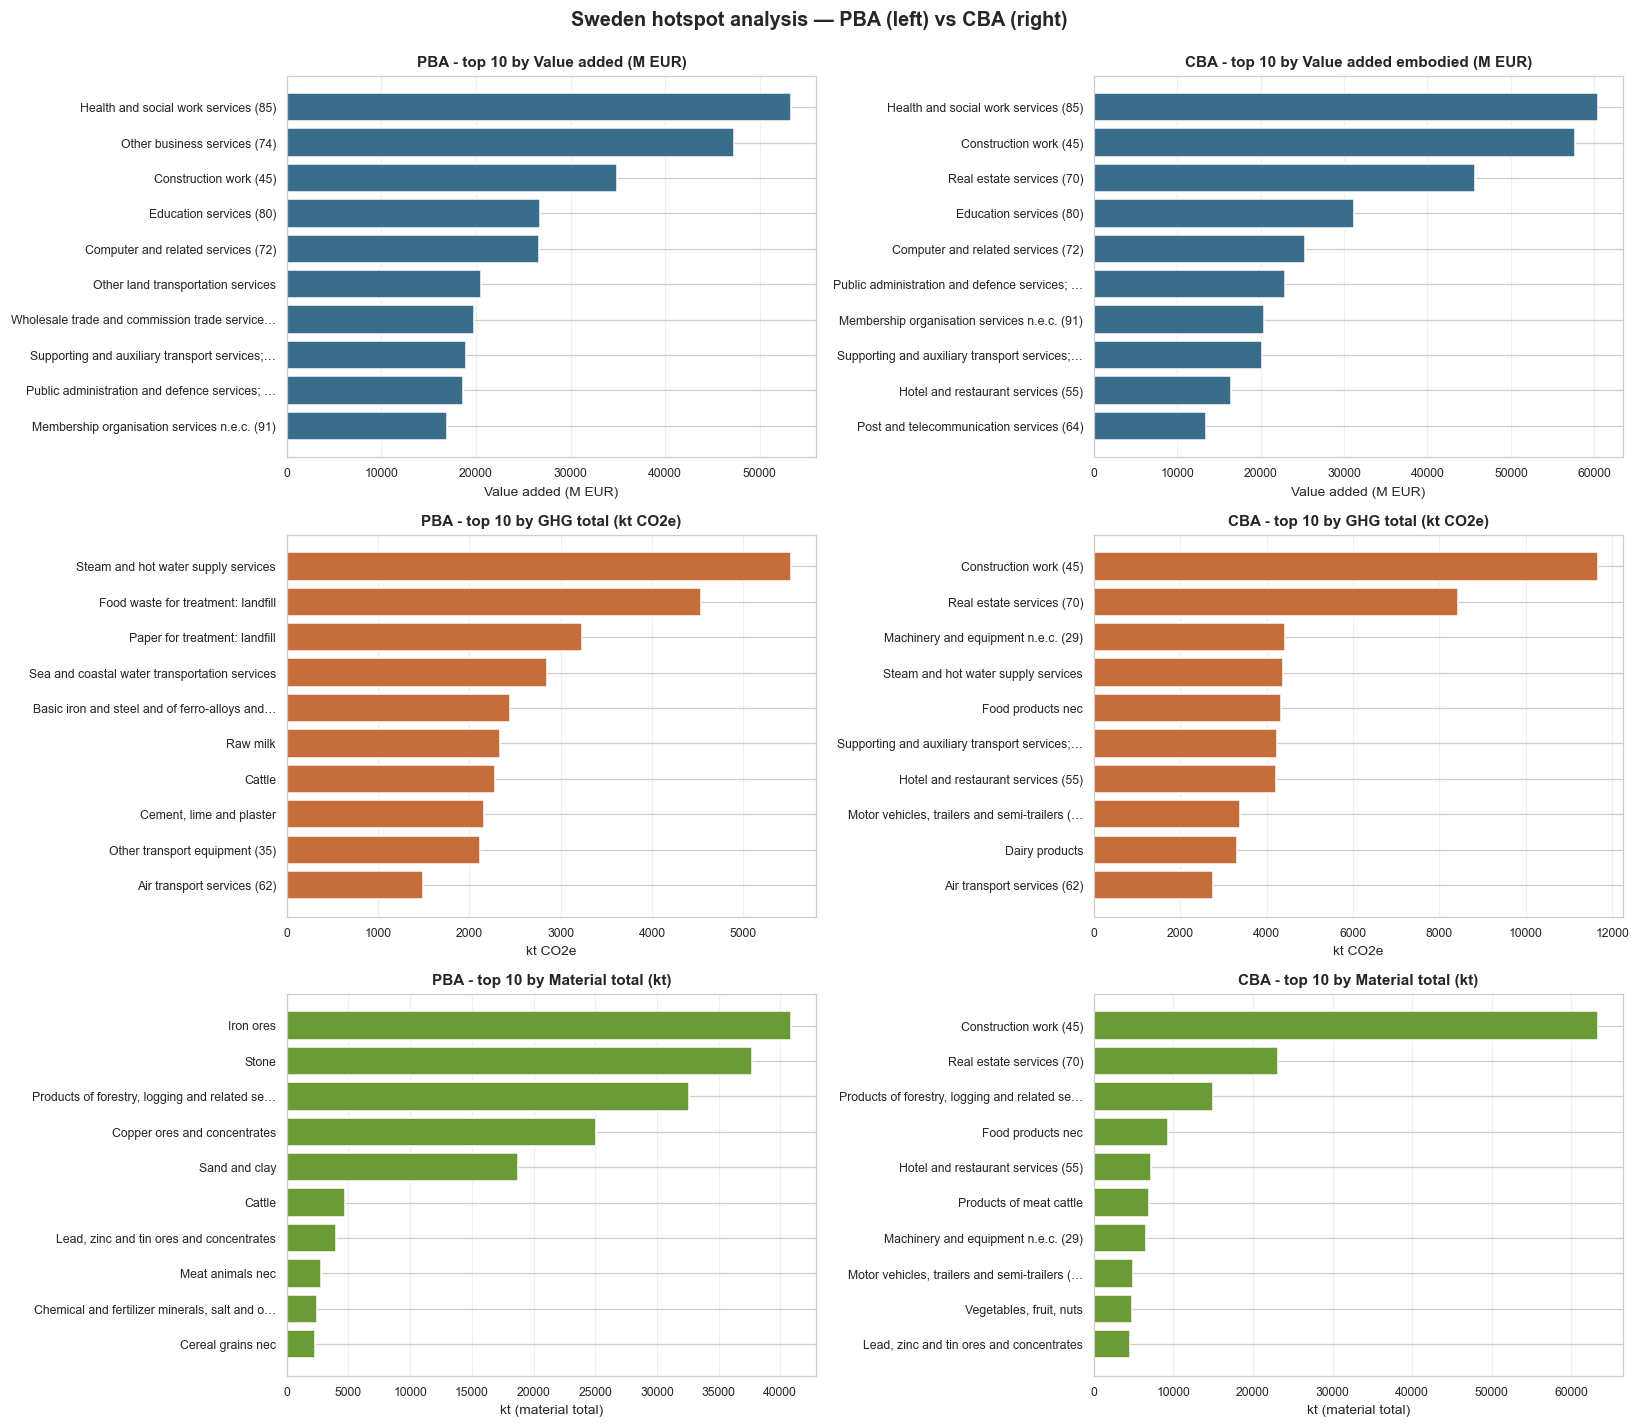

In [30]:
# Compact sector labels (EXIOBASE names are long)
def trim(label, n=45):
    return label if len(label) <= n else label[:n-1] + "…"

def plot_top_horiz(df, col, ax, title, xlabel, color, n=10):
    top = df.nlargest(n, col).iloc[::-1]
    labels = [trim(s) for s in top.index]
    ax.barh(labels, top[col], color=color, edgecolor="white")
    ax.set_title(title, fontsize=10, weight="bold")
    ax.set_xlabel(xlabel, fontsize=9)
    ax.grid(axis="x", alpha=0.3)
    ax.tick_params(labelsize=8)

dims = [
    ("Value added (M EUR)",   "Value added (M EUR)",   "#3a6c8c"),
    ("GHG total (kt CO2e)",   "kt CO2e",               "#c66d3c"),
    ("Material total (kt)",   "kt (material total)",   "#6b9b37"),
]

# CBA side uses the "embodied" value added column
cba_dims = [
    ("Value added embodied (M EUR)", "Value added embodied (M EUR)", "#3a6c8c"),
    ("GHG total (kt CO2e)",          "kt CO2e",                      "#c66d3c"),
    ("Material total (kt)",          "kt (material total)",          "#6b9b37"),
]

fig, axes = plt.subplots(3, 2, figsize=(15, 13))
for i in range(3):
    pba_col, xlab, color = dims[i]
    cba_col, _, _         = cba_dims[i]
    plot_top_horiz(pba_SE, pba_col, axes[i, 0], f"PBA - top 10 by {pba_col}", xlab, color)
    plot_top_horiz(cba_SE, cba_col, axes[i, 1], f"CBA - top 10 by {cba_col}", xlab, color)
fig.suptitle("Sweden hotspot analysis — PBA (left) vs CBA (right)",
             fontsize=13, weight="bold", y=0.995)
fig.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_top_sectors_pba_cba.png", bbox_inches="tight")
plt.show()


### 11.2 Material breakdown per sector (stacked bars)

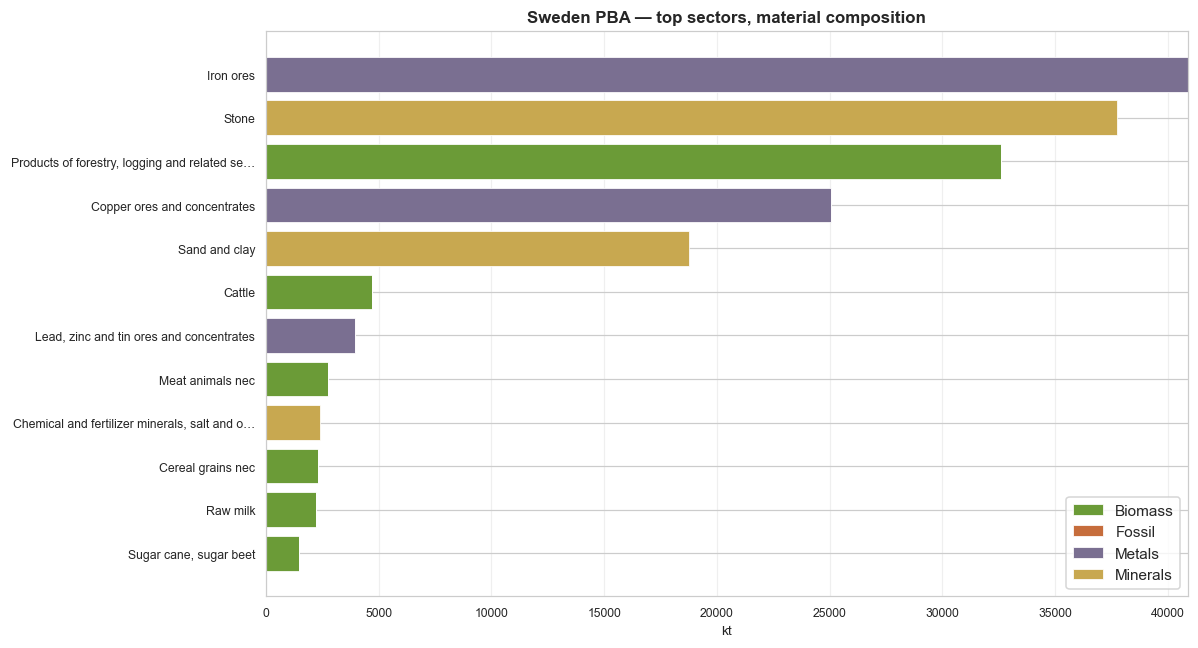

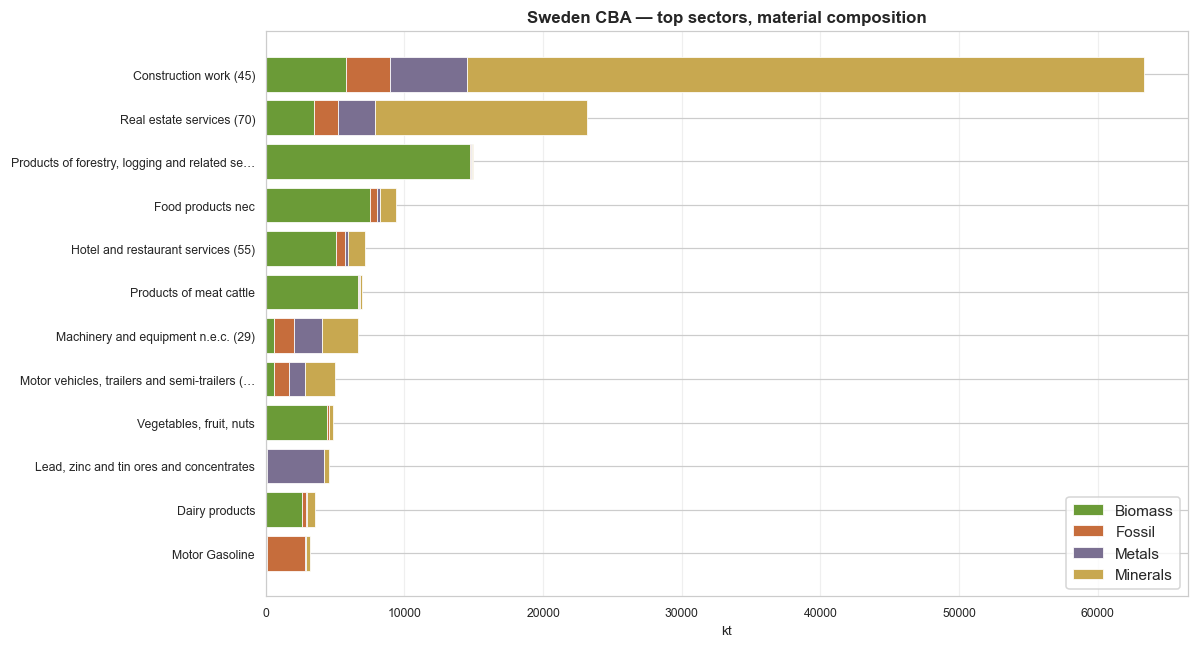

In [31]:
def plot_material_stack(top_sectors, mat_df, title, filename):
    df = mat_df.T.loc[top_sectors].iloc[::-1]
    fig, ax = plt.subplots(figsize=(11, 6))
    colors = {"biomass": "#6b9b37", "fossil": "#c66d3c",
              "metals": "#7a6f91", "minerals": "#c8a850"}
    left = np.zeros(len(df))
    labels = [trim(s) for s in df.index]
    for cat in ["biomass", "fossil", "metals", "minerals"]:
        ax.barh(labels, df[cat], left=left, color=colors[cat], label=cat.capitalize(),
                edgecolor="white", linewidth=0.5)
        left += df[cat].values
    ax.set_xlabel("kt")
    ax.set_title(title, weight="bold")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()

top_pba_mat = pba_SE.nlargest(12, "Material total (kt)").index.tolist()
plot_material_stack(top_pba_mat, F_mat_SE,
                    "Sweden PBA — top sectors, material composition",
                    "fig_material_stack_pba.png")

top_cba_mat = cba_SE.nlargest(12, "Material total (kt)").index.tolist()
plot_material_stack(top_cba_mat, cba_mat_by_sec,
                    "Sweden CBA — top sectors, material composition",
                    "fig_material_stack_cba.png")


### 11.3 Domestic vs imported / exported shares

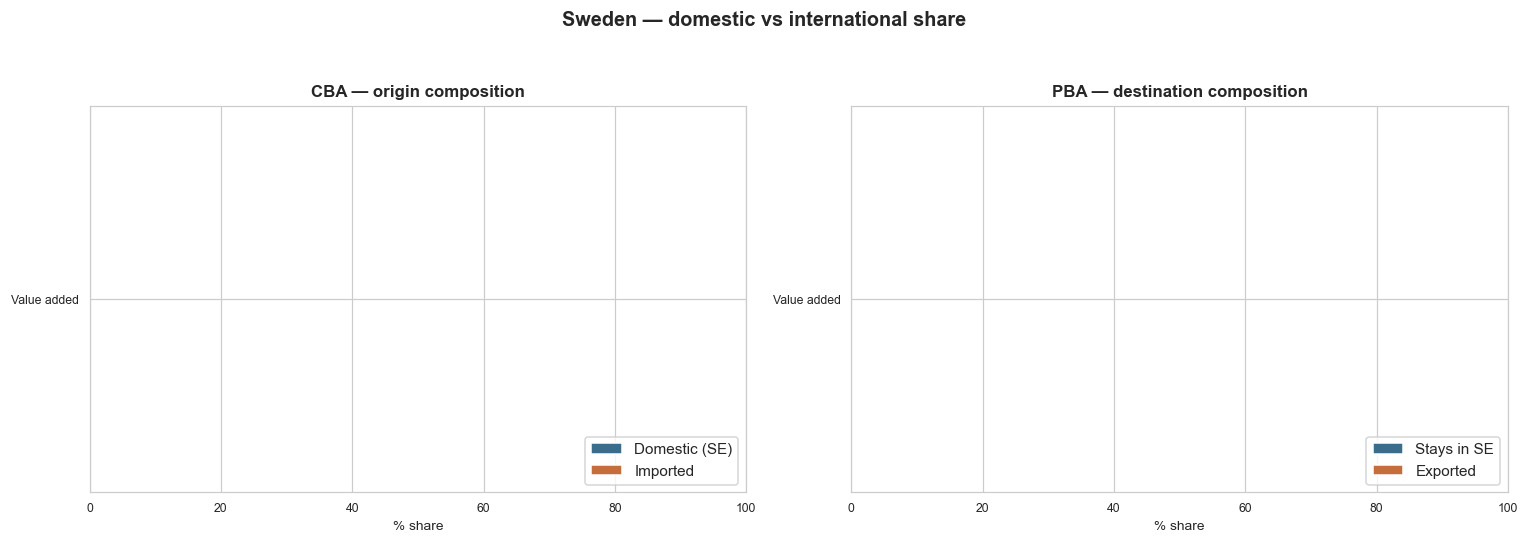

In [32]:
def domestic_imported(series_country):
    dom = series_country.loc[REGION] if REGION in series_country.index else 0
    tot = series_country.sum()
    return dom, tot - dom

dims_plot = [
    ("Value added",  src_va_country,  va_dest_country),
    ("Total GHG",    src_ghg_country, ghg_dest_country),
    ("Material",     src_mat_country, mat_dest_country),
]

cba_vals, pba_vals, names = [], [], []
for name, cba_ser, pba_ser in dims_plot:
    names.append(name)
    d, i_ = domestic_imported(cba_ser); cba_vals.append((d, i_))
    d, e  = domestic_imported(pba_ser); pba_vals.append((d, e))

cba_arr = np.array(cba_vals, dtype=float)
pba_arr = np.array(pba_vals, dtype=float)
cba_pct = cba_arr / cba_arr.sum(axis=1, keepdims=True) * 100
pba_pct = pba_arr / pba_arr.sum(axis=1, keepdims=True) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pct, side_labels, title in [
    (axes[0], cba_pct, ("Domestic (SE)", "Imported"),  "CBA — origin composition"),
    (axes[1], pba_pct, ("Stays in SE",   "Exported"),  "PBA — destination composition"),
]:
    ax.barh(names, pct[:, 0], color="#3a6c8c", label=side_labels[0])
    ax.barh(names, pct[:, 1], left=pct[:, 0], color="#c66d3c", label=side_labels[1])
    ax.set_xlim(0, 100)
    ax.set_xlabel("% share")
    ax.set_title(title, weight="bold")
    ax.legend(loc="lower right")
    for i, (d, o) in enumerate(pct):
        if d > 6:
            ax.text(d/2, i, f"{d:.0f}%", ha="center", va="center",
                    color="white", weight="bold", fontsize=9)
        if o > 6:
            ax.text(d + o/2, i, f"{o:.0f}%", ha="center", va="center",
                    color="white", weight="bold", fontsize=9)

fig.suptitle("Sweden — domestic vs international share", fontsize=13, weight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
plt.savefig(OUTPUT_DIR / "fig_domestic_vs_international.png", bbox_inches="tight")
plt.show()


### 11.4 PBA vs CBA — paired comparison per sector (top 15 by combined impact)

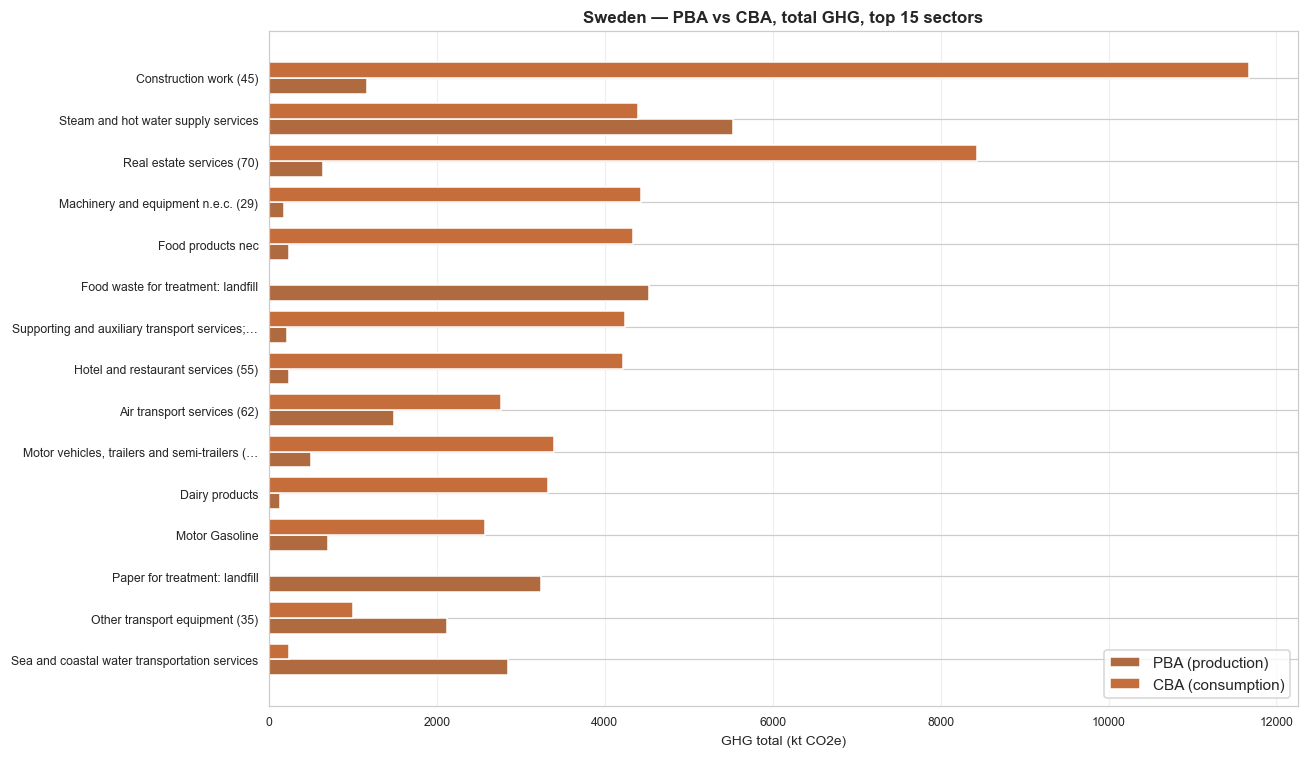

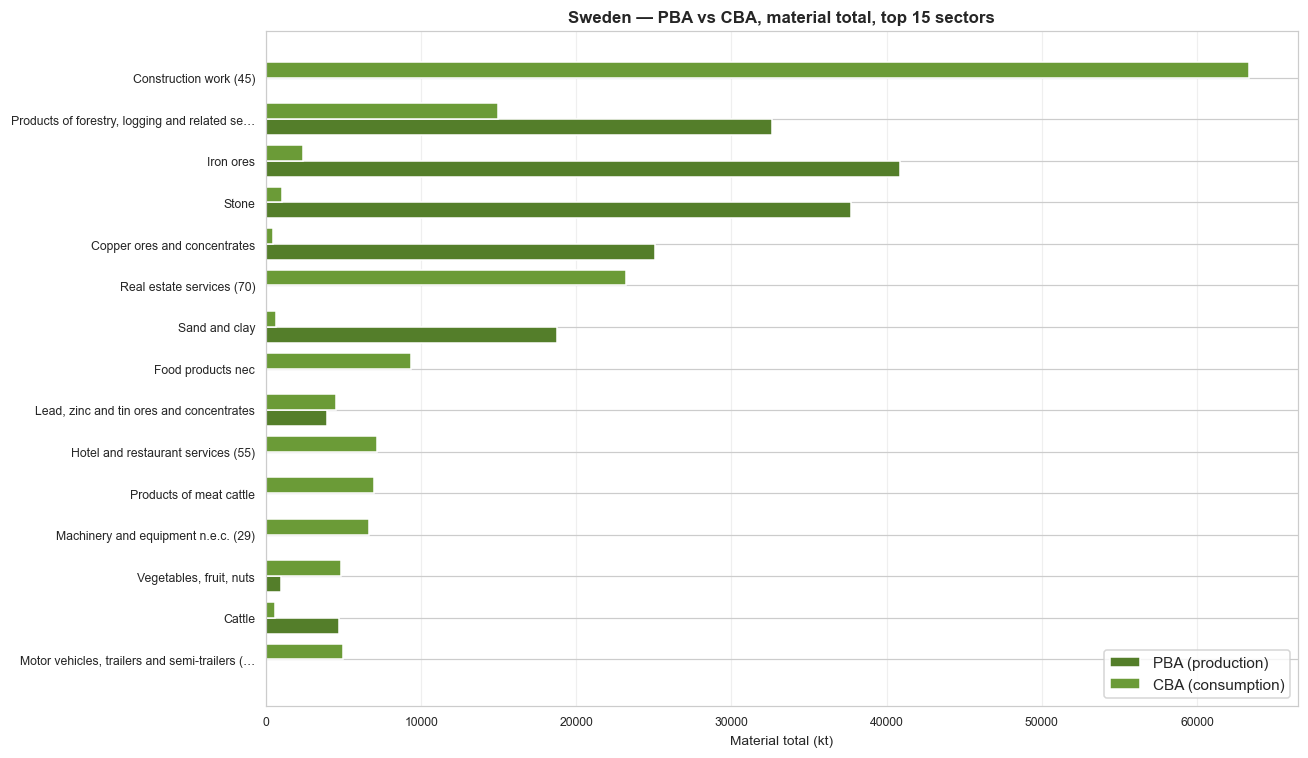

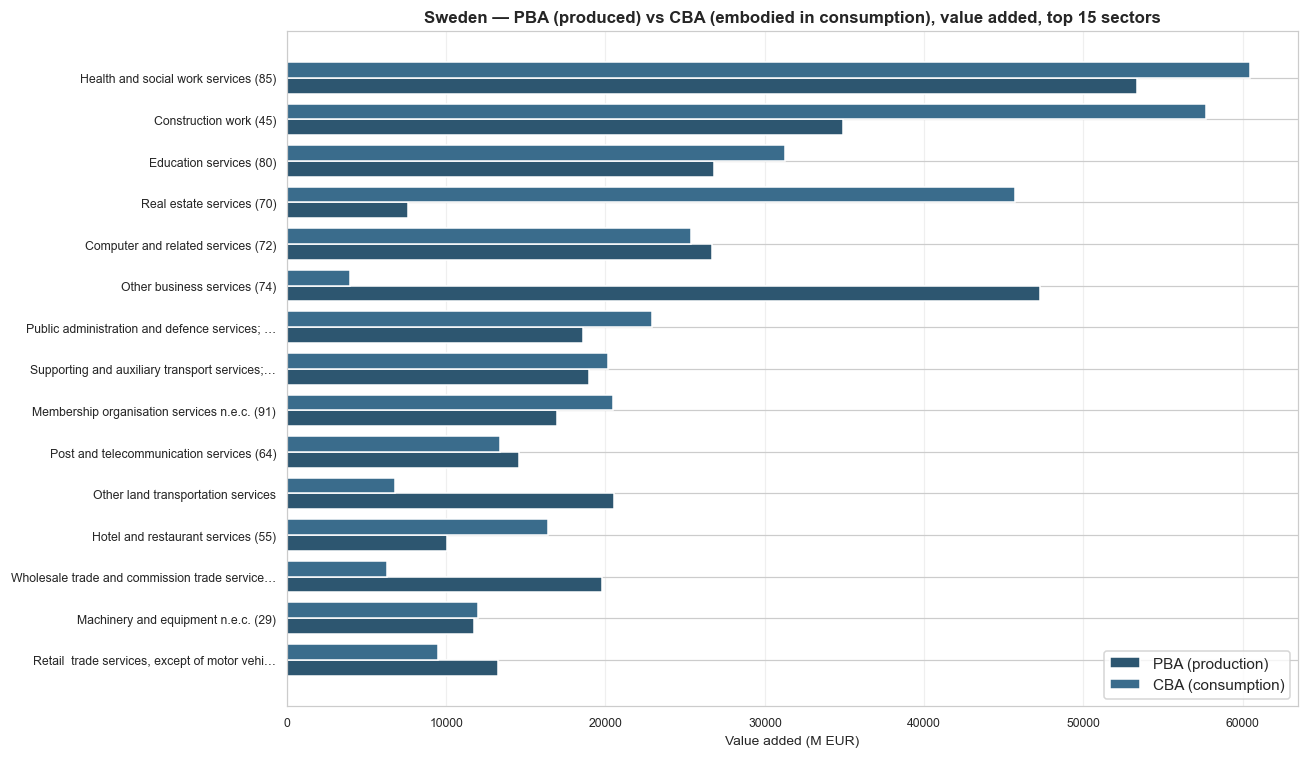

In [33]:
def paired_pba_cba(pba_col, cba_col, display_label,
                   color_pba, color_cba, title, filename, n=15):
    combined = pd.DataFrame({"PBA": pba_SE[pba_col], "CBA": cba_SE[cba_col]}).fillna(0)
    combined["sum"] = combined["PBA"] + combined["CBA"]
    top = combined.nlargest(n, "sum").drop(columns="sum").iloc[::-1]

    fig, ax = plt.subplots(figsize=(12, 7))
    y = np.arange(len(top))
    h = 0.38
    ax.barh(y - h/2, top["PBA"], height=h, label="PBA (production)",
            color=color_pba, edgecolor="white")
    ax.barh(y + h/2, top["CBA"], height=h, label="CBA (consumption)",
            color=color_cba, edgecolor="white")
    ax.set_yticks(y)
    ax.set_yticklabels([trim(s) for s in top.index])
    ax.set_xlabel(display_label)
    ax.set_title(title, weight="bold")
    ax.legend(loc="lower right")
    ax.grid(axis="x", alpha=0.3)
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()

paired_pba_cba("GHG total (kt CO2e)", "GHG total (kt CO2e)",
               "GHG total (kt CO2e)",
               "#b06a3f", "#c66d3c",
               "Sweden — PBA vs CBA, total GHG, top 15 sectors",
               "fig_paired_ghg.png")

paired_pba_cba("Material total (kt)", "Material total (kt)",
               "Material total (kt)",
               "#547e2a", "#6b9b37",
               "Sweden — PBA vs CBA, material total, top 15 sectors",
               "fig_paired_material.png")

paired_pba_cba("Value added (M EUR)", "Value added embodied (M EUR)",
               "Value added (M EUR)",
               "#2d5670", "#3a6c8c",
               "Sweden — PBA (produced) vs CBA (embodied in consumption), value added, top 15 sectors",
               "fig_paired_va.png")


### 11.5 Sankey — CBA source flows

Left column: top (origin country, origin sector) pairs driving Sweden's CBA.
Right column: top Swedish consumption products.

In [34]:
def sankey_source_to_consumption(attrib, title, filename, n_src=15, n_cons=10,
                                  unit_label="",
                                  color_left="#3a6c8c", color_right="#c66d3c"):
    top_src  = attrib.sum(axis=1).nlargest(n_src).index
    top_cons = attrib.sum(axis=0).nlargest(n_cons).index

    sub = attrib.loc[top_src, top_cons]

    left_labels  = [f"{c} — {trim(s, 30)}" for (c, s) in top_src]
    right_labels = [trim(s, 40) for s in top_cons]
    nodes = left_labels + right_labels
    colors = [color_left] * len(left_labels) + [color_right] * len(right_labels)

    sources, targets, values = [], [], []
    for i, src_idx in enumerate(top_src):
        for j, cons in enumerate(top_cons):
            v = sub.loc[src_idx, cons]
            if v > 0:
                sources.append(i)
                targets.append(len(left_labels) + j)
                values.append(float(v))

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(label=nodes, pad=14, thickness=16, color=colors,
                  line=dict(color="white", width=0.5)),
        link=dict(source=sources, target=targets, value=values,
                  color="rgba(120,120,120,0.25)")
    )])
    fig.update_layout(
        title=dict(text=f"{title}  ({unit_label})", font=dict(size=14)),
        font=dict(size=10), height=650, margin=dict(l=10, r=10, t=55, b=10))
    fig.write_html(str(OUTPUT_DIR / filename))
    fig.show()
    return fig

sankey_source_to_consumption(attrib_ghg,
    "Sweden CBA (total GHG) — origin (country, sector) → Swedish consumption",
    "sankey_ghg_source.html", unit_label="kt CO2e")

sankey_source_to_consumption(attrib_mat_total,
    "Sweden CBA (material total) — origin (country, sector) → Swedish consumption",
    "sankey_material_source.html", unit_label="kt")

sankey_source_to_consumption(attrib_va,
    "Sweden CBA (value added) — origin (country, sector) → Swedish consumption",
    "sankey_va_source.html", unit_label="M EUR")


### 11.6 Sankey — PBA destination flows

Left column: top Swedish producing sectors (by PBA).
Right column: destination countries, with Sweden highlighted for the retained share.

In [35]:
def sankey_sector_to_destination(F_dest, pba_series, title, filename,
                                  n_sec=12, n_dest=10, unit_label="",
                                  color_left="#6b9b37", color_right="#3a6c8c"):
    F_dest_country = F_dest.T.groupby(level="region").sum().T   # (200 SE sectors, 49 countries)

    top_secs  = pba_series.nlargest(n_sec).index
    top_dests = F_dest_country.sum(axis=0).nlargest(n_dest).index
    if REGION not in top_dests:
        top_dests = top_dests.tolist() + [REGION]

    sub = F_dest_country.loc[top_secs, top_dests]

    left_labels  = [trim(s, 40) for s in top_secs]
    right_labels = list(top_dests)
    nodes = left_labels + right_labels

    right_colors = ["#a84020" if c == REGION else color_right for c in right_labels]
    colors = [color_left] * len(left_labels) + right_colors

    sources, targets, values = [], [], []
    for i, s in enumerate(top_secs):
        for j, c in enumerate(top_dests):
            v = sub.loc[s, c]
            if v > 0:
                sources.append(i)
                targets.append(len(left_labels) + j)
                values.append(float(v))

    fig = go.Figure(data=[go.Sankey(
        arrangement="snap",
        node=dict(label=nodes, pad=14, thickness=16, color=colors,
                  line=dict(color="white", width=0.5)),
        link=dict(source=sources, target=targets, value=values,
                  color="rgba(120,120,120,0.25)")
    )])
    fig.update_layout(
        title=dict(text=f"{title}  ({unit_label})", font=dict(size=14)),
        font=dict(size=10), height=650, margin=dict(l=10, r=10, t=55, b=10))
    fig.write_html(str(OUTPUT_DIR / filename))
    fig.show()
    return fig

sankey_sector_to_destination(F_ghg_dest, F_ghg_SE,
    "Sweden PBA (total GHG) — Swedish sector → consumer country",
    "sankey_ghg_destination.html", unit_label="kt CO2e")

sankey_sector_to_destination(F_mat_dest_total, F_mat_total_SE,
    "Sweden PBA (material total) — Swedish sector → consumer country",
    "sankey_material_destination.html", unit_label="kt")

sankey_sector_to_destination(F_va_dest, F_va_SE,
    "Sweden PBA (value added) — Swedish sector → consumer country",
    "sankey_va_destination.html", unit_label="M EUR")


### 11.7 Heatmap — country × sector source attribution

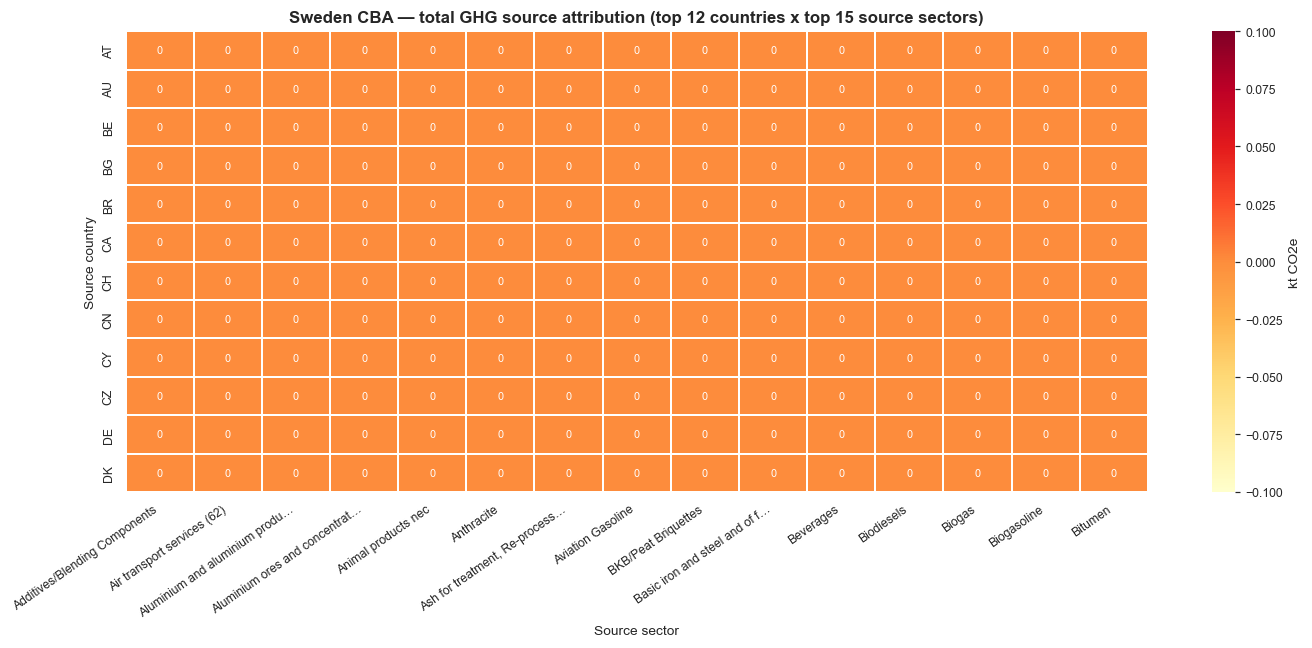

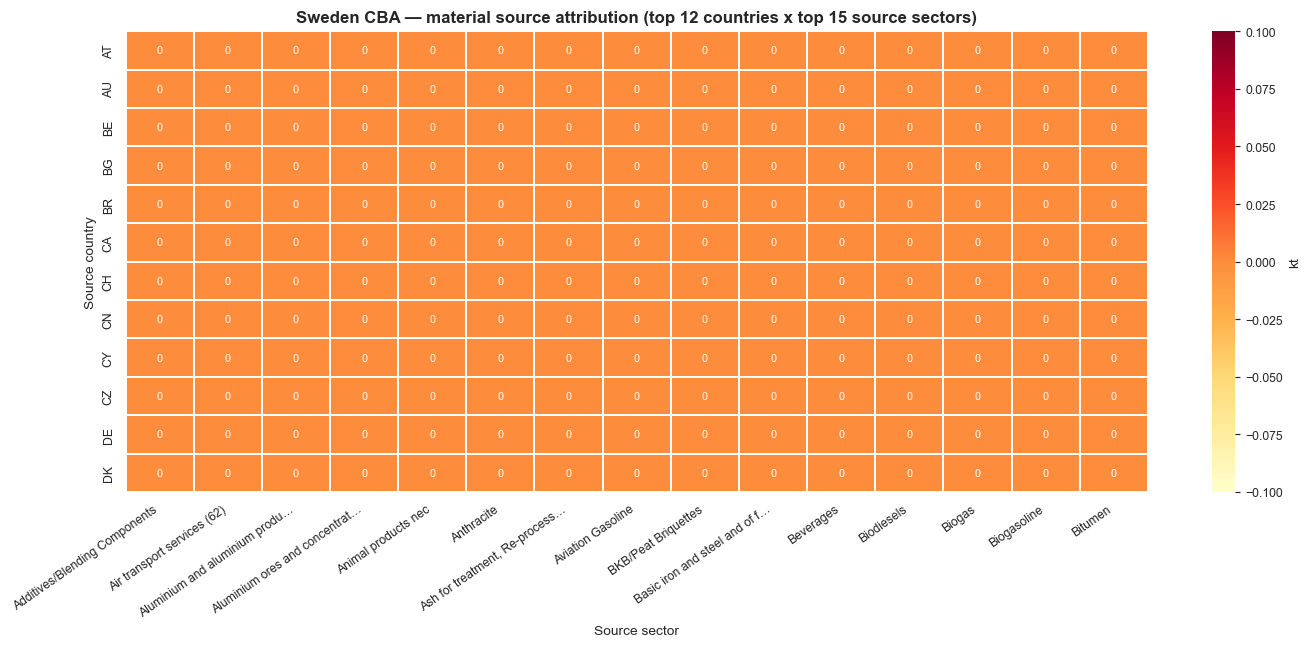

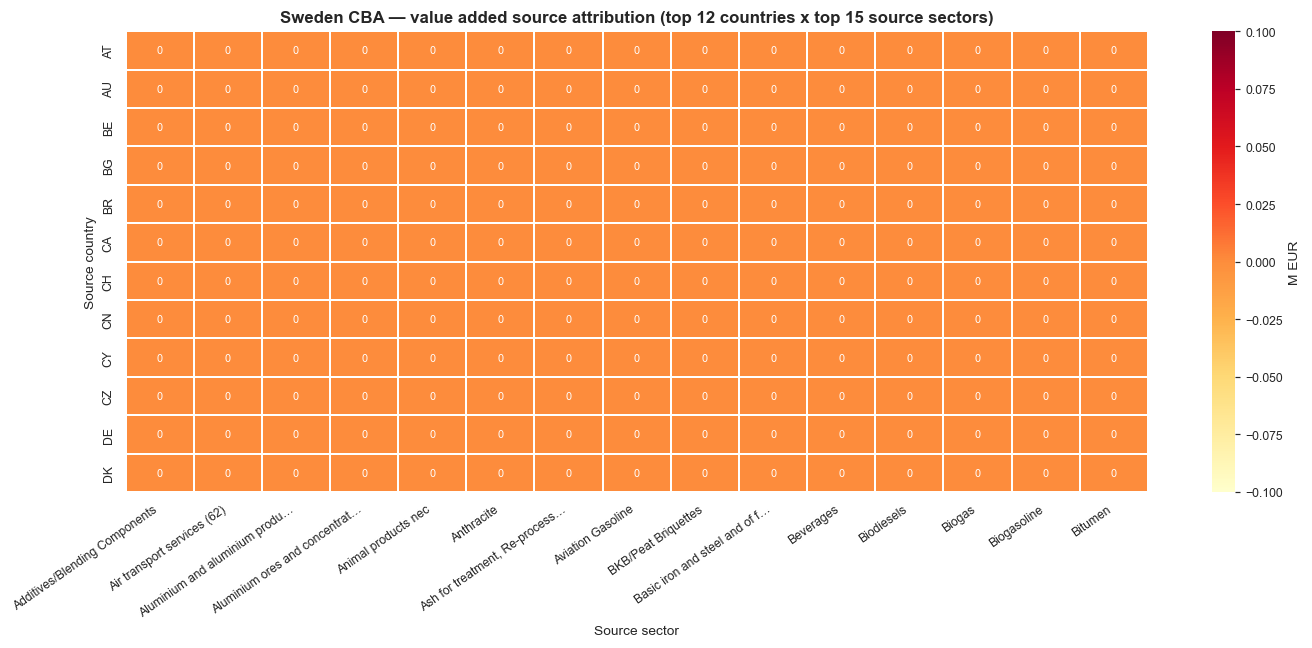

In [36]:
def heatmap_source(src_series, title, filename,
                   n_countries=12, n_sectors=15, unit=""):
    m = src_series.unstack(level="sector").fillna(0)     # (49, 200)
    top_c = m.sum(axis=1).nlargest(n_countries).index
    top_s = m.sum(axis=0).nlargest(n_sectors).index
    sub = m.loc[top_c, top_s]

    fig, ax = plt.subplots(figsize=(13, 6))
    sns.heatmap(sub, cmap="YlOrRd", annot=True, fmt=".0f", linewidths=0.3,
                cbar_kws={"label": unit}, ax=ax, annot_kws={"size": 7})
    ax.set_title(title, weight="bold")
    ax.set_xlabel("Source sector")
    ax.set_ylabel("Source country")
    ax.set_xticklabels([trim(t.get_text(), 30) for t in ax.get_xticklabels()],
                       rotation=35, ha="right")
    fig.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, bbox_inches="tight")
    plt.show()

heatmap_source(src_ghg,
    "Sweden CBA — total GHG source attribution (top 12 countries x top 15 source sectors)",
    "fig_heatmap_ghg.png", unit="kt CO2e")

heatmap_source(src_mat_total,
    "Sweden CBA — material source attribution (top 12 countries x top 15 source sectors)",
    "fig_heatmap_material.png", unit="kt")

heatmap_source(src_va,
    "Sweden CBA — value added source attribution (top 12 countries x top 15 source sectors)",
    "fig_heatmap_va.png", unit="M EUR")


### 11.8 Sunburst — CBA composition (hierarchical view)

Nests the view: country → top source sectors within the country.

In [37]:
def sunburst_cba(src_series, title, filename, n_country=10, n_sector=6, unit=""):
    df = src_series.reset_index()
    df.columns = ["region", "sector", "value"]
    df = df[df["value"] > 0]

    top_c = df.groupby("region")["value"].sum().nlargest(n_country).index
    df["country_label"] = df["region"].where(df["region"].isin(top_c), "Other countries")

    def trim_sectors(sub):
        top_s = sub.groupby("sector")["value"].sum().nlargest(n_sector).index
        sub = sub.copy()
        sub["sector_label"] = sub["sector"].where(sub["sector"].isin(top_s), "Other sectors")
        return sub
    df = df.groupby("country_label", group_keys=False).apply(trim_sectors)
    df_sun = df.groupby(["country_label", "sector_label"])["value"].sum().reset_index()
    df_sun["sector_label"] = df_sun["sector_label"].apply(lambda s: trim(s, 35))

    fig = px.sunburst(
        df_sun, path=["country_label", "sector_label"], values="value",
        color="value", color_continuous_scale="Viridis",
        title=f"{title}  ({unit})",
    )
    fig.update_layout(height=650, margin=dict(l=10, r=10, t=55, b=10))
    fig.write_html(str(OUTPUT_DIR / filename))
    fig.show()
    return fig

sunburst_cba(src_ghg,
    "Sweden CBA — total GHG, country and source sector",
    "sunburst_ghg_source.html", unit="kt CO2e")

sunburst_cba(src_mat_total,
    "Sweden CBA — material total, country and source sector",
    "sunburst_material_source.html", unit="kt")


ValueError: 'country_label' is both an index level and a column label, which is ambiguous.

## 12. Export results

In [ ]:
print(f"Outputs written to {OUTPUT_DIR.resolve()}")
for p in sorted(OUTPUT_DIR.iterdir()):
    size_kb = p.stat().st_size / 1024
    print(f"  {p.name:<45}  {size_kb:>8,.1f} KB")


---

## Notes for the Stockholm disaggregation step

When the Stockholm / Rest-of-Sweden split is layered on top of this notebook, the structure stays the same:

1. The column-copy disaggregation changes only the (region, sector) MultiIndex of every matrix (adds an `STO` region alongside `SE`). All downstream slicing (`REGION = "SE"`) generalises naturally to `REGION = "STO"`.
2. The Leontief inverse must be recomputed after disaggregation (since `A` changes).
3. All aggregations (`aggregate_ghg`, `aggregate_materials`, plus the direct read of `Value Added` from impacts) are index-robust and need no structural changes. The impacts extension rows must be carried through the disaggregation or rebuilt from the split satellite.
4. The known methodological caveat stands: proportional column-copy disaggregation preserves row and column sums but distorts the CBA / PBA ratio for regions much smaller than their parent. Report this alongside any Stockholm results.

## Notes on data version

This notebook targets EXIOBASE 3 **v3.8.2** specifically. If you ever migrate to a newer version (when one becomes available under a commercial-friendly licence), the following helpers will need to be revisited:

- **GHG aggregator** — newer versions may expose `CO2_bio`, `CH4_bio`, `N2O_bio` rows, in which case a fossil-vs-biogenic split becomes honest to compute.
- **Material aggregator** — newer versions use a flat 62-row positional structure rather than the 217-row named structure used here.
- **Value added** — newer versions may use a separate `factor_inputs` extension rather than a pre-computed `Value Added` row in `impacts`.
